In [16]:
#%matplotlib qt
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [17]:
def mostrar_imagen(imagen, titulo=''):
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()

In [18]:
def IQ_measure(imagen):
    F = np.fft.fft2(imagen)
    FC = np.fft.fftshift(F)
    AF = np.abs(FC)
    M = np.max(AF)
    thres = M/1000
    TH = np.count_nonzero(AF > thres)
    IQM = TH / imagen.size
    return M, thres, TH, IQM

In [19]:
def local_sum(imagen, ksize):
    kernel = np.ones((ksize, ksize), dtype=np.float32)
    return cv2.filter2D(imagen, -1, kernel, borderType=cv2.BORDER_REFLECT)

def focus_modified_laplacian(imagen: np.ndarray, ksize: int = 7):
    imagen = imagen.astype(np.float32)

    # Máscaras del paper
    Lx = np.array([[-1, 2, -1]], dtype=np.float32)
    Ly = Lx.T

    dx2 = cv2.filter2D(imagen, -1, Lx, borderType=cv2.BORDER_REFLECT)
    dy2 = cv2.filter2D(imagen, -1, Ly, borderType=cv2.BORDER_REFLECT)

    fml = np.abs(dx2) + np.abs(dy2)
    fml_score = np.mean(local_sum(fml, ksize))
    return fml_score

In [20]:
# Abre el video
video_path = "focus_video.mov"
captura_video = cv2.VideoCapture(video_path)

if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    count_frame = 0
    frames = []
    iqm_values = []
    fml_score_values = []
    
    while True:
        ret, frame = captura_video.read()
        if not ret:
            break
        
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        count_frame += 1
        # Calculamos el Image Quality Measure y el Focus Modified Laplacian
        M, thres, TH, IQM = IQ_measure(frame_gris)
        fml_score = focus_modified_laplacian(frame_gris)
        # Acumulamos los valores de IQM y de FML
        frames.append(count_frame)
        iqm_values.append(IQM)
        fml_score_values.append(fml_score)

best_idx_IQM = np.argmax(iqm_values)
best_frame_IQM = frames[best_idx_IQM]
best_value_IQM = iqm_values[best_idx_IQM]

best_idx_fml = np.argmax(fml_score_values)
best_frame_fml = frames[best_idx_fml]
best_value_fml = fml_score_values[best_idx_fml]

# Libera el objeto de captura de video y cierra todas las ventanas
captura_video.release()
cv2.destroyAllWindows()

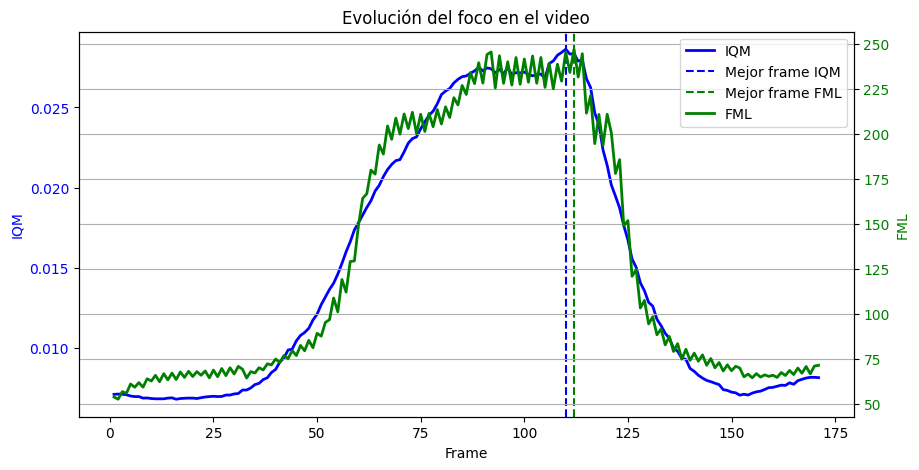

Mejor frame IQM: 110
IQM máximo: 0.02862
Mejor frame FML: 112
FML máximo: 247.10925


In [21]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Eje izquierdo → IQM
ax1.plot(frames, iqm_values, color='blue', linewidth=2, label='IQM')
ax1.set_xlabel("Frame")
ax1.set_ylabel("IQM", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Eje derecho → FML
ax2 = ax1.twinx()
ax2.plot(frames, fml_score_values, color='green', linewidth=2, label='FML')
ax2.set_ylabel("FML", color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Línea vertical (mejor frame)
ax1.axvline(x=best_frame_IQM, color='blue', linestyle='--', label='Mejor frame IQM')
ax1.axvline(x=best_frame_fml, color='green', linestyle='--', label='Mejor frame FML')

# Título
plt.title("Evolución del foco en el video")

# Leyenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

plt.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.grid(True)
plt.show()

print("Mejor frame IQM:", best_frame_IQM)
print("IQM máximo:", round(best_value_IQM, 5))

print("Mejor frame FML:", best_frame_fml)
print("FML máximo:", round(best_value_fml, 5))

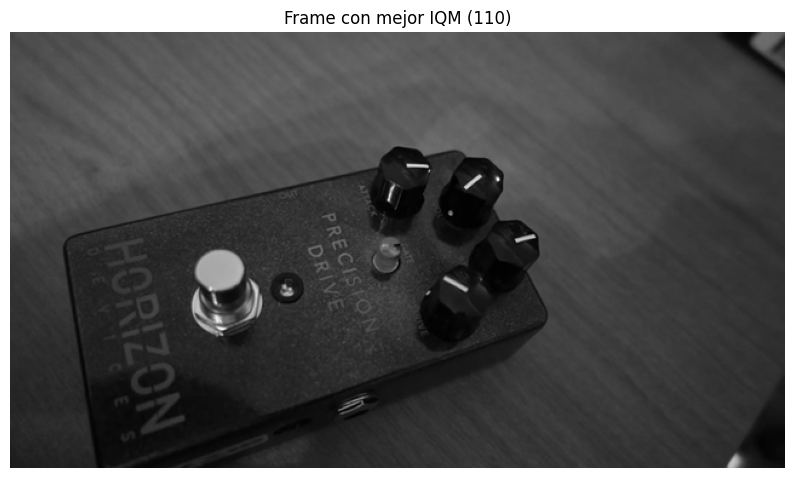

Medidas del frame =  (360, 640)


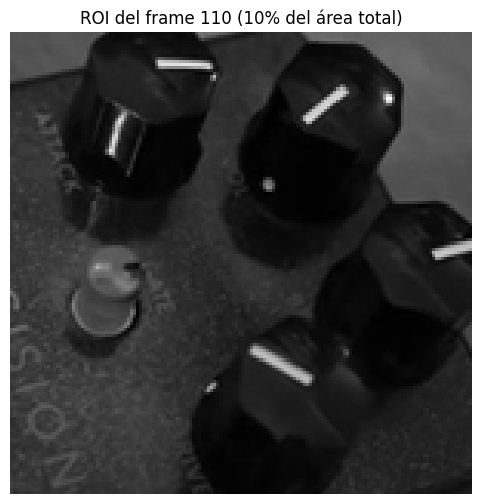

Medidas del ROI =  (150, 150)


In [22]:
# Determinamos la ROI
# Abre el video
video_path = "focus_video.mov"
captura_video = cv2.VideoCapture(video_path)

if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    # Lee el mejro frame y recorta la ROI
    captura_video.set(cv2.CAP_PROP_POS_FRAMES, best_frame_IQM - 1)
    ret, frame = captura_video.read()
    if ret:
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        # Mostrar el frame original y el frame en escala de grises
        mostrar_imagen(frame_gris, titulo=f'Frame con mejor IQM ({best_frame_IQM})')
        print("Medidas del frame = ", frame_gris.shape)
        X_start = 280
        X_stop = X_start + 150
        Y_start = 100
        Y_stop = Y_start + 150
        ROI = frame_gris[(slice(Y_start, Y_stop), slice(X_start, X_stop))]
        mostrar_imagen(ROI, titulo=f"ROI del frame {best_frame_IQM} (10% del área total)")
        print("Medidas del ROI = ", ROI.shape)

# Libera el objeto de captura de video y cierra todas las ventanas
captura_video.release()
cv2.destroyAllWindows()

In [23]:
# Abre el video
video_path = "focus_video.mov"
captura_video = cv2.VideoCapture(video_path)

if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    count_ROI = 0
    ROIs = []
    iqm_values = []
    fml_score_values = []
    
    while True:
        ret, frame = captura_video.read()
        if not ret:
            break
        
        # Procesamiento básico: convertir a escala de grises
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        ROI = frame_gris[(slice(Y_start, Y_stop), slice(X_start, X_stop))]
        count_ROI += 1
        # Calculamos el Image Quality Measure
        M, thres, TH, IQM = IQ_measure(ROI)
        fml_score = focus_modified_laplacian(ROI)
        
        # Acumulamos los valores de IQM y de FML
        ROIs.append(count_ROI)
        iqm_values.append(IQM)
        fml_score_values.append(fml_score)

best_idx_IQM = np.argmax(iqm_values)
best_ROI_IQM = frames[best_idx_IQM]
best_value_IQM = iqm_values[best_idx_IQM]

best_idx_fml = np.argmax(fml_score_values)
best_ROI_fml = frames[best_idx_fml]
best_value_fml = fml_score_values[best_idx_fml]

# Libera el objeto de captura de video y cierra todas las ventanas
captura_video.release()
cv2.destroyAllWindows()

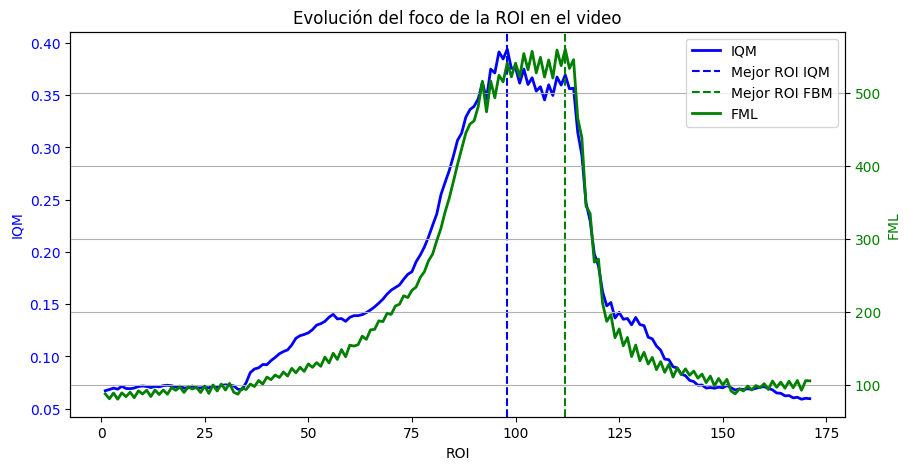

Mejor ROI IQM: 98
IQM máximo: 0.39396
Mejor ROI FML: 112
FML máximo: 559.9241


In [24]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Eje izquierdo → IQM
ax1.plot(ROIs, iqm_values, color='blue', linewidth=2, label='IQM')
ax1.set_xlabel("ROI")
ax1.set_ylabel("IQM", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Eje derecho → FML
ax2 = ax1.twinx()
ax2.plot(ROIs, fml_score_values, color='green', linewidth=2, label='FML')
ax2.set_ylabel("FML", color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Línea vertical (mejor frame)
ax1.axvline(x=best_ROI_IQM, color='blue', linestyle='--', label='Mejor ROI IQM')
ax1.axvline(x=best_ROI_fml, color='green', linestyle='--', label='Mejor ROI FBM')

# Título
plt.title("Evolución del foco de la ROI en el video")

# Leyenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

plt.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.grid(True)
plt.show()

print("Mejor ROI IQM:", best_ROI_IQM)
print("IQM máximo:", round(best_value_IQM, 5))

print("Mejor ROI FML:", best_ROI_fml)
print("FML máximo:", round(best_value_fml, 5))

In [34]:
# Aplico unsharp masking al video
video_path = "focus_video.mov"
captura_video = cv2.VideoCapture(video_path)

if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    count_frame = 0
    frames = []
    #iqm_values_2 = []
    fml_score_values_2 = []
    
    while True:
        ret, frame = captura_video.read()
        if not ret:
            break
        
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        # Suavizar la imagen
        gauss = cv2.GaussianBlur(frame_gris, (7,7), 1.5)
        # Aplicar la máscara de enfoque:    
        k=0.5
        frame_gris_sharp = cv2.addWeighted(frame_gris, k+1, gauss, -k, 0)
        # Mostrar el frame enfocado
        cv2.imshow('Video enfocado', frame_gris_sharp)   
        
        count_frame += 1
        # Calculamos el Image Quality Measure
        #M, thres, TH, IQM = IQ_measure(frame_gris_sharp)
        # Acumulamos los valores de IQM enfocado
        #frames.append(count_frame)
        #iqm_values_2.append(IQM)
        
        # Calculamos el Focus Modified Laplacian
        fml_score = focus_modified_laplacian(frame_gris_sharp)
        fml_score_values_2.append(fml_score)
        frames.append(count_frame)

        # Espera de 25 ms y opción de salir con q
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break

# Libera el objeto de captura de video y cierra todas las ventanas
captura_video.release()
cv2.destroyAllWindows()

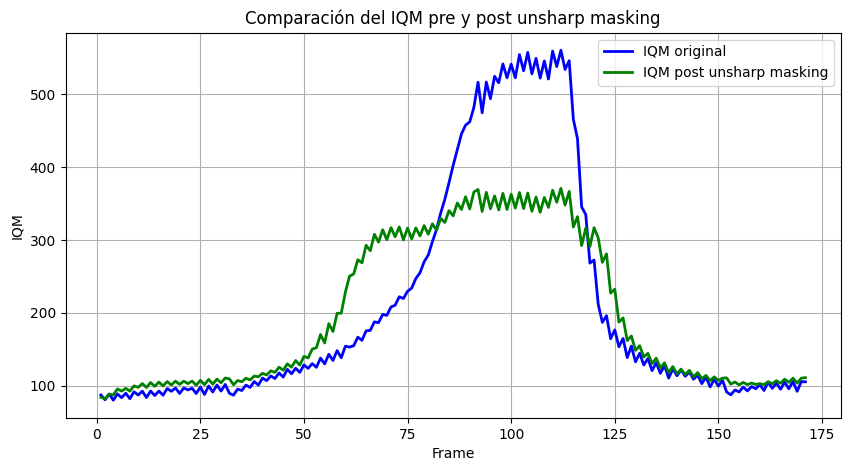

In [35]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(frames, fml_score_values, color='blue', linewidth=2, label='IQM original')
ax1.plot(frames, fml_score_values_2, color='green', linewidth=2, label='IQM post unsharp masking')

# Labels
ax1.set_xlabel("Frame")
ax1.set_ylabel("IQM")

# Título
plt.title("Comparación del IQM pre y post unsharp masking")

# Leyenda
plt.legend()

# Grid
plt.grid(True)

plt.show()